# [LAB] Surrogate Models for XAI — LIME & SHAP

## Overview

In this lab you will apply **surrogate model** techniques to explain how ML models make decisions.

| Technique | What it does | When to use |
|-----------|-------------|-------------|
| **LIME (text)** | Highlights which words drove a prediction | Text classification |
| **LIME (image)** | Highlights which image regions matter | Image classification |
| **SHAP** | Fair attribution via Shapley values | Regression / any model |

### What you will build

1. A **Naive Bayes** text classifier on 20 Newsgroups — then explain individual predictions with LIME
2. An **MLP** image classifier on Olivetti faces — then visualize superpixel contributions
3. An **XGBoost** regression model on Boston Housing — then analyze feature impacts globally

> Stuck? Refer to the **solution notebook** `[0430]4.Surrogate_solution.ipynb`.

## Section 0 — Setup

Run the cell below once. It installs `lime`, `scikit-image`, `shap`, and `xgboost` if they are not already installed.

In [ ]:
# TODO: Run this cell as-is to install/import required packages
def ensure_package(package_name):
    import subprocess, sys
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name, '-q'])

ensure_package('lime')
ensure_package('scikit-image')
ensure_package('shap')
ensure_package('xgboost')


## Section 1 — Introduction to Surrogate Models & LIME

**Surrogate models** approximate complex "black-box" ML models with a simpler, interpretable model — *locally*, near one prediction at a time.

**LIME** (Local Interpretable Model-agnostic Explanations) works in three steps:

```
1. Pick one prediction to explain
2. Perturb the input (turn words/pixels on & off) and get the black-box's responses
3. Fit a simple linear model on those perturbations — the weights are your explanation
```

LIME is **model-agnostic**: it works with any classifier as long as you can call `predict_proba(input)`.

> Key limitation: LIME assumes local linearity and may differ across runs (stochastic sampling). Always check stability by running explain_instance multiple times.

**In this lab you will use LIME to explain:**
- A text classifier (Naive Bayes on 20 Newsgroups)
- An image classifier (MLP on Olivetti faces)
- A regression model (XGBoost on Boston Housing) — via **SHAP** (a more theoretically grounded alternative)

## Section 2 — Text Classification with Naive Bayes

**Concept:** The 20 Newsgroups dataset contains ~20,000 newsgroup posts across 20 topics — perfect for multi-class text classification. We use **Multinomial Naive Bayes** with **TF-IDF** features as our black-box model. Despite being interpretable on its own, treating it as a black box lets us practice LIME in a well-understood setting.

| Step | What we do |
|------|-----------|
| TF-IDF | Convert raw text into numeric feature vectors (word frequencies) |
| Naive Bayes | Train a probabilistic classifier assuming word independence |
| Pipeline | Chain TF-IDF + NB so one call handles preprocessing + prediction |

**What to observe:** Check the F1-score and note which classes are harder to distinguish.  
**Try it yourself:** After training, predict on `newsgroups_test.data[0]` and print the top 3 predicted categories.

In [ ]:
# TODO (1): Load the 20 newsgroups training & test datasets
# from sklearn.datasets import fetch_20newsgroups
# newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
# newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))
# Observe: Print number of documents and category names

# YOUR CODE HERE


In [ ]:
# TODO (2): Create a pipeline: TfidfVectorizer → MultinomialNB
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.naive_bayes import MultinomialNB
# Build and fit pipeline on newsgroups_train
# Observe: Print training accuracy

# YOUR CODE HERE


In [ ]:
# TODO (3): Evaluate on test set and show top predictions for test doc 0
# Compute accuracy on test set
# Show top 5 predicted categories with probabilities

# YOUR CODE HERE


## Section 3 — LIME for Text Explanation

**Concept:** LIME for text perturbs a document by randomly removing words, collects the black-box model's responses to each perturbed version, and fits a sparse linear model. The resulting **coefficients** show which words most influenced the prediction — positive weights push toward the predicted class, negative weights push away.

**What to observe:**
- Do the highlighted words make intuitive sense for the predicted newsgroup?
- Compare the explanation for a *high-confidence* vs. *low-confidence* prediction.

**Try it yourself:** Change `top_labels=1` to `top_labels=3` in `explain_instance` and call `exp.show_in_notebook()` to see explanations for multiple classes at once.

In [ ]:
# TODO (4): Explain test document 0 using LIME
# from lime.lime_text import LimeTextExplainer
# Create explainer with class names from newsgroups_train
# Generate explanation for newsgroups_test.data[0]
# Observe: Which words most strongly support the prediction?
# Try: exp.show_in_notebook(text=True)

# YOUR CODE HERE


In [ ]:
# Example 5.6  Generate LIME explanation for test document 0
# explain_instance samples perturbed texts and fits a local linear model

exp = explainer.explain_instance(
    newsgroups_test.data[0],   # the document to explain
    pipe.predict_proba,         # classifier function
    top_labels=1               # explain only the top predicted class
)

split() requires a non-empty pattern match.


In [ ]:
# Example 5.7  Check which class labels are available in the explanation
print("Available labels in explanation:", exp.available_labels())
print("Corresponds to class:", [class_names[i] for i in exp.available_labels()])

[7]

In [ ]:
# Example 5.8  Visualize the LIME explanation inline in the notebook
# Highlighted words in green increase confidence; red words decrease it.

exp.show_in_notebook(text=newsgroups_test.data[0])

In [ ]:
# Example 5.9  Explain test document 5 — observe how the explanation differs
from lime.lime_text import LimeTextExplainer

idx = 5

explainer = LimeTextExplainer(class_names=class_names)
exp = explainer.explain_instance(newsgroups_test.data[idx], pipe.predict_proba, top_labels=1)
predict_classes = pipe.predict_proba([newsgroups_test.data[idx]]).round(3)[0]
rank = sorted(range(len(predict_classes)), key=lambda i: predict_classes[i], reverse=True)

print(f"Document id   : {idx}")
print(f"Predicted class: {class_names[nb.predict(test_vectors[idx]).reshape(1,-1)[0,0]]}")
print(f"True class     : {class_names[newsgroups_test.target[idx]]}")
print(f"\nTop predicted class: {class_names[rank[0]]}")
print("Top 5 influential words:")
for word, weight in exp.as_list(rank[0])[:5]:
    direction = "↑ supports" if weight > 0 else "↓ opposes"
    print(f"  {word:20s}  {direction}  ({weight:+.4f})")

exp.show_in_notebook(text=newsgroups_test.data[idx])

split() requires a non-empty pattern match.


Document id: 5
Predicted class: med
True class: med
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[13, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]
Explanation for class med
('fungus', 0.001639867543079976)
('infection', 0.001604138623743136)
('yeast', 0.0015525958446041238)
('Candida', 0.0014802492187345109)
('candida', 0.0014374954360360217)
('ocom', 0.0014308177163502465)
('infections', 0.0012992497818976093)
('mucosal', 0.001231287901317231)
('Yeast', 0.0012205686521592895)
('deficiency', 0.001130419477412044)


**Q1:** Look at the LIME explanation for test document 0.
- Which words most strongly support the predicted class?
- Do you think those words are genuinely meaningful, or could they be spurious correlations?

**Answer:** *(Write your answer here)*

In [ ]:
# TODO (6): Train MLP on Olivetti faces
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import Normalizer
# from sklearn.neural_network import MLPClassifier
# Build pipeline: Normalizer → MLPClassifier(hidden_layer_sizes=(64,), max_iter=500)
# Fit and evaluate on test set
# Observe: Aim for 95%+ test accuracy

# YOUR CODE HERE


(-0.5, 63.5, 63.5, -0.5)

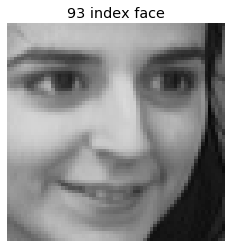

In [ ]:
# Example 5.11  Display a single face image to inspect the data

index = 93
plt.figure(figsize=(4, 4))
plt.imshow(X_vec[index], cmap='gray')
plt.title(f'Face index {index}  (individual {y_vec[index]})')
plt.axis('off')
plt.show()

## Section 4 — LIME for Image Explanation

**Concept:** For images, LIME segments the image into **superpixels** (coherent regions using SLIC/quickshift), then randomly turns superpixels on/off to create perturbed versions. After collecting the classifier's predictions on each perturbation, it fits a linear model — the superpixel weights reveal which *regions* drove the classification decision.

```
Original image
  → Segment into superpixels
  → Create 1,000 perturbed versions (some regions hidden)
  → Run classifier on each
  → Fit linear model on perturbation–prediction pairs
  → Top positive superpixels = what the model "sees"
```

**What to observe:** Green regions = positive evidence for the predicted class. Do they correspond to expected facial features (eyes, nose, jaw)?

**Try it yourself:** Change the segmenter to `'quickshift'` or `'felzenszwalb'` and compare the resulting superpixel shapes and explanation stability.

In [ ]:
# TODO (7): Use LIME to explain an MLP prediction on a face image
# from lime.lime_image import LimeImageExplainer
# Create explainer and select a test image (e.g., index 15)
# Generate LIME explanation with superpixel segmentation
# Observe: Which facial regions are important? Do they match your intuition?
# Try different segmentation methods (slic, quickshift, felzenszwalb)

# YOUR CODE HERE


In [ ]:
# Example 5.15  Fit the MLP pipeline on training data (may take ~30 seconds)

simple_pipeline.fit(X_train, y_train)
print("Training complete.")

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


Pipeline(memory=None,
         steps=[('Make Gray', <__main__.PipeStep object at 0x7f4ebe359ac8>),
                ('Flatten Image', <__main__.PipeStep object at 0x7f4ebe359668>),
                ('MLP',
                 MLPClassifier(activation='relu', alpha=0.0001,
                               batch_size='auto', beta_1=0.9, beta_2=0.999,
                               early_stopping=False, epsilon=1e-08,
                               hidden_layer_sizes=(400, 40),
                               learning_rate='constant',
                               learning_rate_init=0.001, max_fun=15000,
                               max_iter=200, momentum=0.9, n_iter_no_change=10,
                               nesterovs_momentum=True, power_t=0.5,
                               random_state=1, shuffle=True, solver='adam',
                               tol=0.0001, validation_fraction=0.1,
                               verbose=False, warm_start=False))],
         verbose=False)

In [ ]:
# Example 5.18  Best-performing pipeline configuration
# Larger hidden layers + smaller alpha (L2 regularisation) + smaller epsilon improve accuracy.

simple_pipeline = Pipeline([
    ('Make Gray',     makegray_step),
    ('Flatten Image', flatten_step),
    ('Normalize',     Normalizer()),
    ('MLP', MLPClassifier(
        activation='relu',
        alpha=1e-7,
        epsilon=1e-6,
        hidden_layer_sizes=(800, 120),
        random_state=1)),
])

simple_pipeline.fit(X_train, y_train)

print("=== Best pipeline performance ===")
test_model(X_test, y_test)

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      1.00      1.00         3
           2       1.00      0.25      0.40         4
           3       1.00      0.60      0.75         5
           4       1.00      1.00      1.00         3
           5       0.33      1.00      0.50         1
           6       0.00      0.00      0.00         1
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       0.80      0.80      0.80         5
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       0.33      1.00      0.50         1
          13       0.80      1.00      0.89         4
          14       0.67      1.00      0.80         2
          15       0.67      1.00      0.80         2
          16       0.00      0.00      0.00         0
          17       1.00    

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


In [ ]:
# Example 5.19  Declare the LIME Image Explainer and the SLIC segmentation algorithm
# Segmentation splits the image into superpixels — LIME then turns them on/off.

from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

explainer = lime_image.LimeImageExplainer()

# Available segmentation algorithms: 'quickshift' (default), 'slic', 'felzenszwalb'
segmenter = SegmentationAlgorithm(
    'slic',
    n_segments=100,    # number of superpixels
    compactness=1,     # higher = more square-shaped segments
    sigma=1)           # Gaussian smoothing before segmentation

print("LIME Image Explainer ready. Segmentation algorithm: SLIC")

In [ ]:
# Example 5.20  Build the surrogate explanation model for Olivetti test image 0
# (%%time is not available in all kernels; we use perf_counter instead)

from time import perf_counter

olivetti_test_index = 0

start_time = perf_counter()
exp = explainer.explain_instance(
    X_test[olivetti_test_index],
    classifier_fn = simple_pipeline.predict_proba,
    top_labels=6,
    num_samples=1000,
    segmentation_fn=segmenter)
elapsed_time = perf_counter() - start_time
print(f"Elapsed: {elapsed_time:.2f}s")

CPU times: user 2.85 s, sys: 916 ms, total: 3.77 s
Wall time: 2.11 s


Text(0.5, 1.0, 'Show mask only')

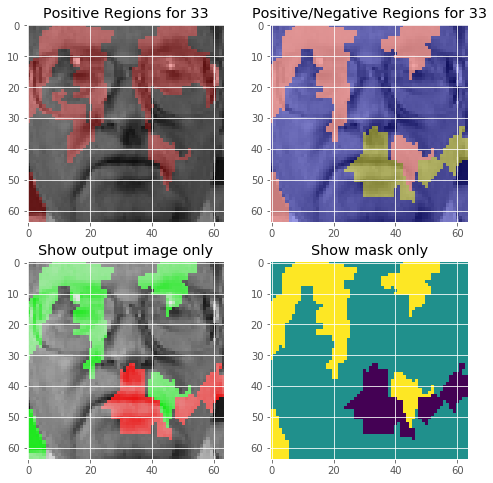

In [ ]:
# Example 5.21  Visualize the LIME explanation for Olivetti test image 0

from skimage.color import label2rgb

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

# ── Positive regions (what supports the prediction) ──
temp, mask = exp.get_image_and_mask(
    y_test[olivetti_test_index],
    positive_only=True, num_features=8, hide_rest=False)
ax1.imshow(label2rgb(mask, temp, bg_label=0), interpolation='nearest')
ax1.set_title(f'Positive regions → class {y_test[olivetti_test_index]}')
ax1.axis('off')

# ── Both positive and negative regions ──
temp, mask = exp.get_image_and_mask(
    y_test[olivetti_test_index],
    positive_only=False, num_features=8, hide_rest=False)
ax2.imshow(label2rgb(4 - mask, temp, bg_label=0), interpolation='nearest')
ax2.set_title('Positive / Negative regions')
ax2.axis('off')

# ── Original image ──
ax3.imshow(temp, interpolation='nearest')
ax3.set_title('Original image')
ax3.axis('off')

# ── Mask only ──
ax4.imshow(mask, interpolation='nearest')
ax4.set_title('Superpixel mask')
ax4.axis('off')

plt.tight_layout()

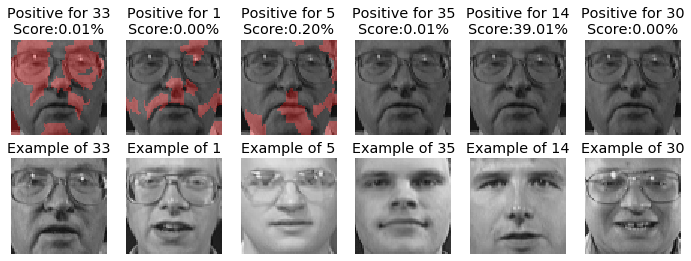

In [ ]:
# Example 5.22  Visualize explanations for top-6 predicted classes side by side
# Each column: left = LIME explanation, right = a ground truth example of that class

def show_extra_info(test, test_index):
    pipe_pred_prop = simple_pipeline.predict_proba(test)
    fig, m_axs = plt.subplots(2, 6, figsize=(12, 4))
    for i, (c_ax, gt_ax) in zip(exp.top_labels, m_axs.T):
        temp, mask = exp.get_image_and_mask(
            i, positive_only=True, num_features=12,
            hide_rest=False, min_weight=0.001)
        c_ax.imshow(label2rgb(mask, temp, bg_label=0), interpolation='nearest')
        c_ax.set_title(f'Class {i}\n{100*pipe_pred_prop[test_index, i]:.1f}%')
        c_ax.axis('off')

        face_id = np.random.choice(np.where(y_train == i)[0])
        gt_ax.imshow(X_train[face_id])
        gt_ax.set_title(f'Example {i}')
        gt_ax.axis('off')

    plt.suptitle(f'Test image {test_index}: LIME explanation (top) vs. reference faces (bottom)',
                 fontsize=10)
    plt.tight_layout()

show_extra_info(X_test, 1)

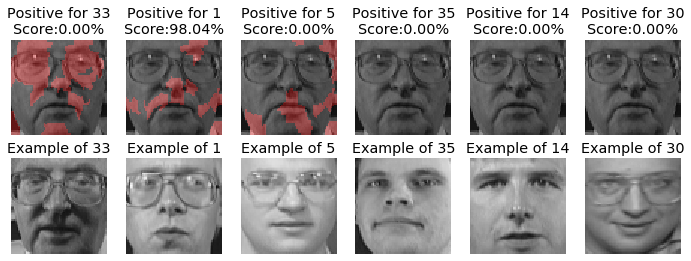

In [ ]:
# TODO: Try a different test image index (e.g., 25) and observe the explanation
show_extra_info(X_test, 25)

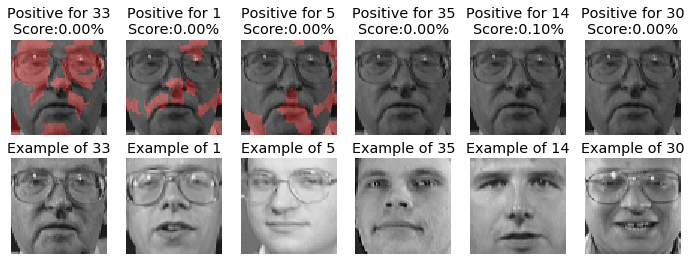

In [ ]:
# TODO: Try another test image index (e.g., 101) — does the explanation look reasonable?
show_extra_info(X_test, 101)

**Q2:** Look at the face explanation images (positive/negative regions).
- Which facial regions seem most important for identifying different individuals?
- Why might the model rely on background regions? Is that a problem?

**Answer:** *(Write your answer here)*

## Section 5 — SHAP: SHapley Additive exPlanations

**Concept:** SHAP is grounded in **cooperative game theory**. It assigns each feature a *Shapley value* — the feature's average marginal contribution across all possible orderings of features.

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

Unlike LIME, SHAP guarantees three key properties:

| Property | Meaning |
|----------|---------|
| **Local accuracy** | SHAP values sum exactly to the model output |
| **Missingness** | Features absent in input get SHAP = 0 |
| **Consistency** | If a feature matters more in a new model, its SHAP value won't decrease |

**TreeSHAP** computes exact Shapley values for tree-based models (XGBoost, LightGBM) in polynomial time — no sampling needed.

**Dataset: Boston Housing** — 506 data points, 13 features predicting median home value (MEDV) in $1,000s.

In [ ]:
# TODO (8): Load Boston Housing data and split
# from sklearn.datasets import fetch_openml
# from sklearn.model_selection import train_test_split
# Load data: fetch_openml(name='boston', version=1, as_frame=True)
# Split X, y into train/test (80/20, random_state=42)
# Observe: Feature names, target statistics (mean, std)

# YOUR CODE HERE


Text(0, 0.5, 'MEDV \n Price $1,000')

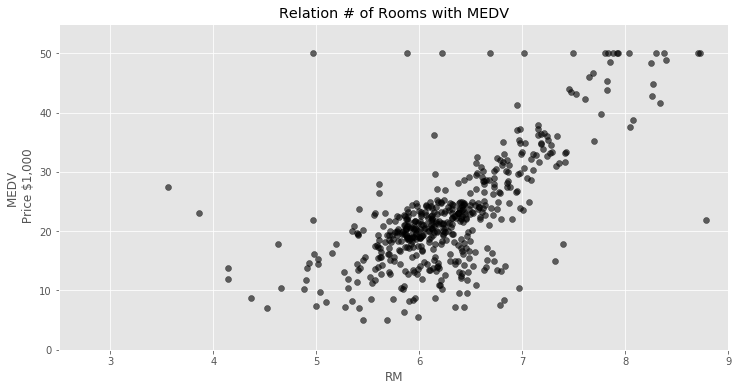

In [ ]:
# Example 5.23 (continued)  Scatter plot: number of rooms (RM) vs. home price (MEDV)
# A positive correlation is visible — more rooms → higher price, but not perfectly linear.

import matplotlib.pylab as plt
import matplotlib
%matplotlib inline
matplotlib.style.use('ggplot')

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
ax1.scatter(X['RM'], y, color='black', alpha=0.6)
ax1.set_title('Boston Housing: Number of Rooms (RM) vs. Home Price (MEDV)')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM — Average number of rooms')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV — Median home value ($1,000s)')
plt.tight_layout()

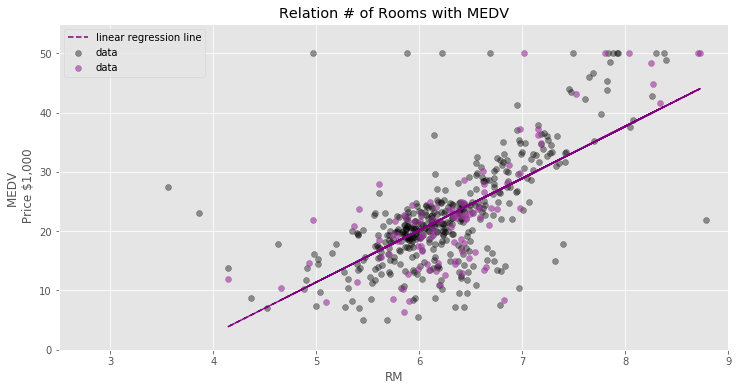

In [ ]:
# Example 5.39  Overlay the linear regression line on the scatter plot

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
ax1.scatter(X_train['RM'], y_train, color='black', alpha=0.4, label='Train data')
ax1.scatter(X_test['RM'],  y_test,  color='#993299', alpha=0.6, label='Test data')
ax1.plot(X_test['RM'], prediction, color='purple', linestyle='--', label='Linear regression (RM only)')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM — Average number of rooms')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV — Median home value ($1,000s)')
ax1.set_title('Linear Regression: RM → MEDV')
ax1.legend()
plt.tight_layout()

## Section 6 — XGBoost Regression Baseline

**Concept:** Before applying SHAP, we train an XGBoost regressor as our black-box model. A simple linear regression using only the `RM` (rooms) feature serves as a **baseline surrogate** — easy to interpret, but less accurate than the full XGBoost model.

| Model | Features | Expected RMSE |
|-------|---------|---------------|
| Linear regression (RM only) | 1 feature | ~6.5 |
| XGBoost (all 13 features) | 13 features | ~3.2 |

**What to observe:** How much does adding more features (via XGBoost) reduce the RMSE?  
**Try it yourself:** Try `n_estimators=200` in XGBRegressor — does the RMSE improve?

In [ ]:
# TODO (9): Train XGBoost regressor on Boston Housing
# from xgboost import XGBRegressor
# model = XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
# Fit on training data
# Compute R² on train and test sets
# Observe: Any overfitting? Compare to a simple baseline (e.g., mean prediction)

# YOUR CODE HERE


In [ ]:
# TODO (10): Compute SHAP values using TreeExplainer
# import shap
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test)
# base_value = explainer.expected_value
# Observe: Shape of shap_values, computation time

# YOUR CODE HERE


Text(0, 0.5, 'MEDV \n Price $1,000')

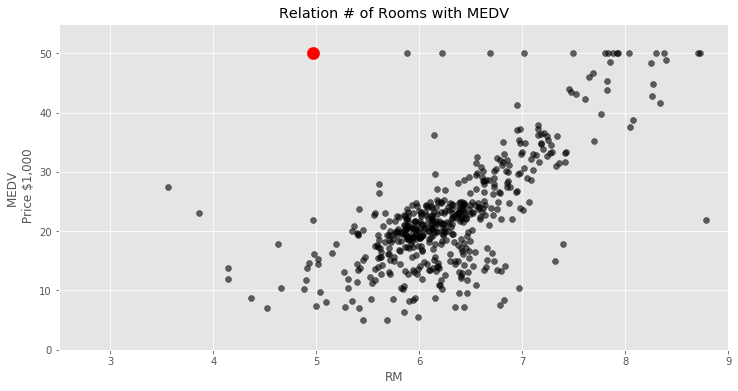

In [ ]:
# Example 5.44  Highlight data point 259 on the scatter plot
# Red dot = the specific data point we will explain with SHAP

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
idx = 259

ax1.scatter(X['RM'], y, color='black', alpha=0.6, label='All data')
ax1.scatter(X_train['RM'].iloc[idx], y_train.iloc[idx],
            c='red', s=150, zorder=5, label=f'Data point {idx}')
ax1.set_title(f'Boston Housing: data point {idx} highlighted (red)')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV ($1,000s)')
ax1.legend()
plt.tight_layout()
print(f"Data point {idx}: RM = {X_train['RM'].iloc[idx]:.2f}, "
      f"actual price = ${y_train.iloc[idx]:.1f}k")

## Section 7 — SHAP Force Plots: Explaining Single Predictions

**Concept:** A **force plot** shows a single prediction as a tug-of-war between features:

```
base value ──[LSTAT pushes ←]──[RM pushes →]──[RAD pushes ←]──► actual prediction
```

- **Base value** (`base_value`): the average model prediction across all training samples
- **Red bars**: features that increase the prediction (push price up)
- **Blue bars**: features that decrease the prediction (push price down)

The SHAP values sum exactly to: `prediction = base_value + Σ(shap_values)`

**What to observe:** For data point 259, check which feature has the largest absolute SHAP value. Does this match your intuition about the feature's influence on price?

**Try it yourself:** Find a training sample with a very high predicted price (`preds` array) and another with a very low price — compare their force plots. Do different features dominate?

In [ ]:
# Example 5.45  Force plot for data point 259
# base_value was computed in the cell above (equals explainer.expected_value)

shap.initjs()

# TODO: Call shap.force_plot for training sample index 259
# Hint: shap.force_plot(base_value, shap_values[259, :], X_train.iloc[259, :], matplotlib=True)
shap.force_plot(base_value, shap_values[259, :], X_train.iloc[259, :], matplotlib=True)

In [ ]:
# TODO (12): Visualize stacked force plot for all test samples
# shap.force_plot(base_value, shap_values, X_test, matplotlib=True)
# Observe: Patterns in feature contributions? Clusters?

# YOUR CODE HERE


**Q3:** Look at the stacked force plot (all training data).  
- Which features appear most consistently red (raising predictions)?
- Do the clusters in the stacked plot suggest any interesting patterns?

**Answer:** *(Write your answer here)*

## Section 8 — SHAP Global Analysis: Dependence & Summary Plots

**Concept:** While force plots explain *one prediction*, global SHAP visualizations reveal *overall* feature behavior:

| Plot | What it shows |
|------|--------------|
| **Dependence plot** | SHAP value vs. feature value for one feature (colored by interaction partner) |
| **Summary (beeswarm)** | All features ranked by mean \|SHAP\|; each dot is one data point |
| **Summary (bar)** | Same ranking as bar chart — global feature importance via SHAP |

**Reading the beeswarm plot:**
- **Y-axis position** = feature (ranked by importance, top = most important)
- **X-axis** = SHAP value (positive = increases prediction)
- **Dot color** = feature value (red = high, blue = low)
- Pattern: *"red dots on right"* means high feature value → higher prediction

**What to observe:** Compare the SHAP-based global importance with XGBoost's built-in `plot_importance`. Do they rank features the same way? Where do they disagree?

**Try it yourself:** Call `shap.dependence_plot("LSTAT", shap_values, X_train)` — which feature does SHAP choose as the interaction coloring variable, and why?

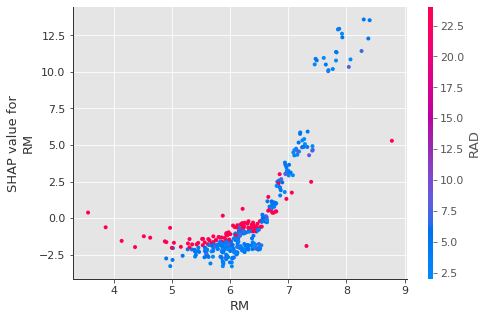

In [ ]:
# Example 5.47  SHAP Dependence Plot: RM feature
# X-axis: RM value | Y-axis: SHAP value | Color: automatically chosen interaction feature
# Upward trend = higher RM → higher price contribution

shap.dependence_plot("RM", shap_values, X_train)

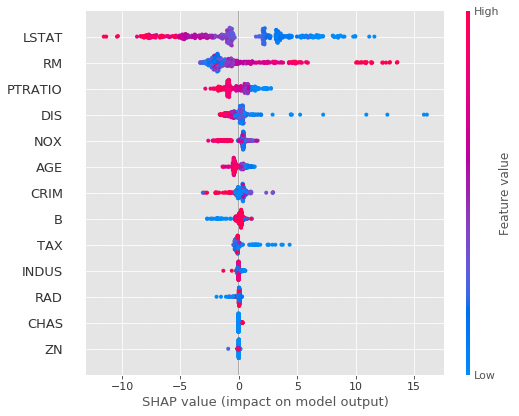

In [ ]:
# Example 5.48  SHAP Beeswarm Summary Plot
# Each dot = one data point; color = feature value (red=high, blue=low)
# Features sorted top-to-bottom by mean |SHAP| (most important at top)

shap.summary_plot(shap_values, X_train)

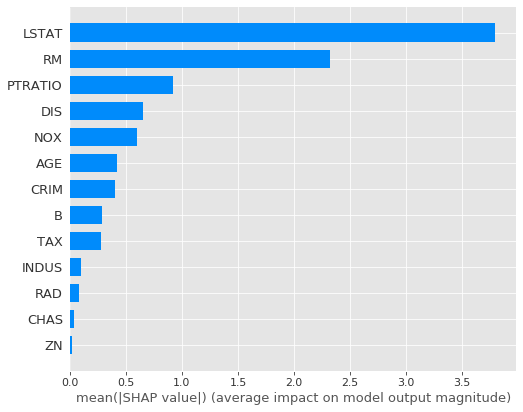

In [ ]:
# Example 5.49  SHAP Bar Summary Plot — mean |SHAP| per feature (global importance ranking)

shap.summary_plot(shap_values, X_train, plot_type="bar")

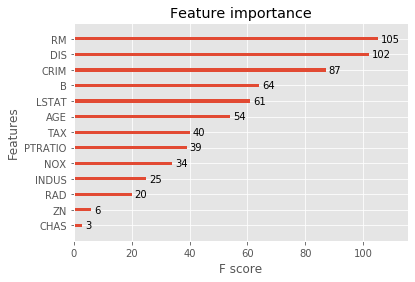

In [ ]:
# Example 5.50  XGBoost built-in feature importance
# Compare this ranking to the SHAP bar plot above — do they agree?

import xgboost
xgboost.plot_importance(model)
plt.title("XGBoost Built-in Feature Importance (F-score)")
plt.tight_layout()

## Lab Complete — Review Questions

**Q4:** Compare LIME and SHAP in your own words.
- Which method gave you more intuitive explanations?
- Which method do you trust more, and why?

**Answer:** *(Write your answer here)*

---

**Q5:** LIME explanations can change if you run them again (stochastic). SHAP (TreeSHAP) gives deterministic results. How does this difference affect your confidence in each method's explanations?

**Answer:** *(Write your answer here)*

---

### Key Takeaways

| | LIME | SHAP |
|---|---|---|
| **Approach** | Local perturbation + linear surrogate | Shapley values (game theory) |
| **Model-agnostic?** | Yes | Yes (TreeSHAP is tree-specific) |
| **Consistency** | Stochastic — results may vary | Deterministic (TreeSHAP) |
| **Global explanations** | Limited | Yes (summary, dependence plots) |
| **Speed** | Slow (sampling) | Fast for tree models |

> Both methods are complementary. In practice, use SHAP for global insights and LIME when you need fast, model-agnostic local explanations.